# Week5 Probabilistic View of Linear Regression

Linear regression is a fundamental statistical and machine learning technique used to model the relationship between a dependent variable (response variable) and one or more independent variables (predictors). The probabilistic view of linear regression extends the classic least squares perspective by incorpora
ting uncertainty and providing a probabilistic interpretation of the predictions and parameters.

## 0. Gaussian Distribution Review
In probability theory and statistics, a normal distribution or Gaussian distribution is **a type of continuous probability distribution** for a real-valued random variable. The general form of its probability density function is
$$p(x)=\mathcal{N}(x\mid\mu,\sigma^2)=\frac{1}{\sqrt{2\pi}\sigma}\exp(-\frac{(x-\mu)^2}{2\sigma^2})$$
- The parameter $\mu$ is the mean or expectation of the distribution (and also its median and mode), while - The parameter $\sigma^2$ is the variance.
- The standard deviation (std) of the distribution is $\sigma$.
- A random variable with a Gaussian distribution is said to be normally distributed, and is called a normal deviate.
           <img src="./figures/gaussian.png" alt="Alt text" width="400" height="300" style="display: block; margin-left: auto; margin-right: auto;">
Image source [wiki](https://en.wikipedia.org/wiki/Normal_distribution)

## 1. Classic Linear Regression

The goal of linear regression is to find a linear relationship between the dependent variable $y$ and the independent variables $X$. In the simplest form with a single feature, it is expressed as:

$$ y = X \theta + \epsilon $$

where:
- $X$ is a matrix of independent variables (also known as features),
- $\theta$ is a vector of coefficients,
- $\epsilon$ is a random error term.


## 2. Probabilistic Interpretation

In the probabilistic view, we assume that the observations are drawn from a distribution rather than having deterministic values. This means we consider the error term $\epsilon$ as a random variable and, consequently, $y$ itself as a random variable.
<img src="/figures/prob_LR.png" alt="Alt text" width="400" height="300" style="display: block; margin-left: auto; margin-right: auto;">
Image source: [medium blog](https://towardsdatascience.com/probabilistic-interpretation-of-linear-regression-clearly-explained-d3b9ba26823b)

The probabilistic model of linear regression can be expressed as:
$$
y^i \sim \mathcal{N}(\mu_i, \sigma^2)
$$

where:

- $y^i$: Observed value for the $i$-th sample
- $\mu_i = \theta^Tx^i$: Mean of the distribution, which is the predicted value from the linear model
- $\sigma^2$: Variance of the error term, assumed to be constant for all observations
- $\mathcal{N}(\mu_i, \sigma^2)$: Normal distribution with mean $\mu_i$ and variance $\sigma^2$

In other words, for each observation, the model assumes that $y^i$ is drawn from a normal distribution centered around  $\mu_i$ with variance $ \sigma^2 $.

## 3. Likelihood Function

The likelihood function measures the probability of observing the data given the parameters $\theta$, and $\sigma^2 $. Assuming $n$independent observations $(x^1,y^1),..., (x^n,y^n)$, the likelihood function is given by:

$$
p(\vec{y} \mid X;\theta) = \prod_{i=1}^{n} \mathcal{N}(y^i \mid \mu_i, \sigma^2)
$$

- where $\mu_i = \theta^T x_i $.
- The notation $p(y^i \mid x^i;\theta)$ indicates that this is the distribution of $y^i$ given $x^i$ and parameterized by $\theta$.
- We should not condition on $\theta (p(y^i|x^i,\theta))$ because $\theta$ is not a random variable.
- Given X (the design matrix, which contains all the $x^i$) and $\theta$, what is the distribution of the $\vec{y}$? The probability of the data is given by $p(\vec{y}|X;\theta)$
- This quantity is typically viewed a function of $\vec{y}$ for a fixed value of $\theta$. We call is the **likelihood** function when we view it as an explicit function of $\theta$. $L(\theta)=p(\vec{y}|X;\theta)$
  
\begin{align}
L(\theta)=p(\vec{y} \mid X;\theta) &= \prod_{i=1}^{n} \mathcal{N}(y^i \mid \mu_i, \sigma^2)\\
&=\prod_{i=1}^{n}\frac{1}{\sqrt{2\pi}\sigma}\exp (-\frac{(y^i-\mu_i)^2}{2\sigma^2})
\end{align}

**Given this probabilistic model relating $y^i$ and $x^i$, what is a reasonable way of choosing our best guess of the parameters $\theta$?**
- **The principal of maximum likelihood says that we should choose $\theta$ so as to make the data as high probability as possilbe. i.e., we should choose $\theta$ to maximize $L(\theta)$.**

The logarithm of the likelihood function, known as the **log-likelihood**, is often used for simplicity:
\begin{align}
l(\theta) &= \log L(\theta)\\
&=\log p(\vec{y} \mid X;\theta)\\
&=\log \prod_{i=1}^{n}\frac{1}{\sqrt{2\pi}\sigma}\exp (-\frac{(y^i-\mu_i)^2}{2\sigma^2})\\
&= \sum_{i=1}^n\log\frac{1}{\sqrt{2\pi}\sigma}\exp (-\frac{(y^i-\mu_i)^2}{2\sigma^2})\\
&=n\log\frac{1}{\sqrt{2\pi}\sigma} - \frac{1}{\sigma^2}\cdot \frac{1}{2} \sum_{i=1}^{n} (y^i - \mu_i)^2\\
&=-\frac{n}{2} \log(2\pi) - \frac{n}{2} \log(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y^i - \mu_i)^2
\end{align}
- Maximizing log-likelihood $l(\theta)$ gives the same answer as minimizing
 $$\frac{1}{2}\sum_{i=1}^{n} (y^i - \mu_i)^2=\frac{1}{2}\sum_{i=1}^{n} (y_i - \theta^Tx^i)^2$$
**which is the loss function of least-square** 
This shows that the least squares approach is, in fact, a maximum likelihood estimation under the assumption of normally distributed errors.

## 4. Maximum Likelihood Estimation (MLE)

To find the best parameters $\theta_0 $, and $\sigma^2 $, we maximize the log-likelihood function. This is equivalent to minimizing the residual sum of squares (RSS):

$$
\text{RSS} = \sum_{i=1}^{n} (y_i - \mu_i)^2
$$

## 5. Bayesian Linear Regression
Bayesian linear regression is an extension of the traditional linear regression model. **Instead of estimating a single value for the coefficients ($\theta$), Bayesian regression estimates the distribution over the possible values of the coefficients($\theta$)**. This approach allows for incorporating prior beliefs and updating them with observed data.

In linear regression, we model the relationship between a dependent variable $ y$ and an independent variable $ X $ as:
$$ y = X \theta + \epsilon $$
where:
- $X$ is a matrix of independent variables (also known as features),
- $\theta$ is a vector of coefficients,
- $\epsilon$ is a random error term.

**In Bayesian linear regression, we treat $\theta$ as a random variable and place a prior distribution over it**. We then update this prior with the observed data to obtain a posterior distribution.

### Prior Distribution $p(\theta)$

The prior distribution reflects our beliefs about the coefficients before seeing the data. A common choice for the prior is a Gaussian distribution:
$$p(\theta) = \mathcal{N}(\theta\mid \mu_0, \sigma_0)$$
where:
- $\mu_0 $ is the prior mean,
- $\sigma_0 $ is the prior covariance matrix.

### Likelihood $p(\vec{y}\mid X,\theta)$

The likelihood function describes the probability of the observed data given the coefficients:
$$p(\vec{y} \mid X, \theta) = \mathcal{N}(y \mid X, \theta)$$
where $\sigma^2 $ is the variance of the error term $\epsilon$.

### Posterior Distribution $p(\theta\mid X,\vec{y})$

The posterior distribution combines the prior distribution and the likelihood function using **Bayes' theorem**:
$$ \text{posterior}=\frac{\text{likelihood}\times\text{prior}}{\text{evidence}}=p(\theta \mid X, \vec{y}) = \frac{p(y \mid X, \theta) p(\theta)}{p(\vec{y} \mid X)} \propto p(\vec{y} \mid X, \theta) p(\theta)$$

The posterior distribution is also a Gaussian distribution with mean $\mu_N$ and covariance $\Sigma_N$:
The Bayesian model can be written as:
- **Prior**: $p(\theta)$
- **Likelihood**: $p(\vec{y} \mid X, \theta)$
- **Posterior**: $p(\theta \mid X, \vec{y}) \propto p(\vec{y} \mid X, \theta) \cdot p(\theta)$
  
In Bayesian linear regression, we take a prior distribution over the parameters $\theta$ and update this distribution using the observed data to get a posterior distribution. This gives a distribution over the parameters rather than point estimates.

## 6. Loss function for Bayesian Linear Regression: Maximum A Posteriori (MAP) Estimation
The Maximum A Posteriori (MAP) estimation incorporates a prior distribution into the estimation process, which allows us to express our prior beliefs about the parameters. The MAP estimator is given by:
$$
\theta_{\text{MAP}} = \underset{\theta}{\text{argmax}} \, p(\theta | \mathbf{y}, X)
$$
Using Bayes' theorem, we can express this as:
$$
p(\theta | \mathbf{y}, X) = \frac{p(\mathbf{y} | X, \theta) \, p(\theta)}{p(\mathbf{y} | X)}
$$

Since $p(\mathbf{y} | X)$ does not depend on $\theta $, we can simplify the expression to:

$$
\theta_{\text{MAP}} = \underset{\theta}{\text{argmax}} \, p(\mathbf{y} | X, \theta) \, p(\theta)
$$

Taking the logarithm (since it is a monotonic function, it does not change the location of the maximum), we get the log-posterior:
$$
\log p(\theta | \mathbf{y}, X) = \log p(\mathbf{y} | X, \theta) + \log p(\theta)
$$
### Likelihood Term
The log-likelihood term is the same as in MLE:

$$
\log p(\mathbf{y} | X, \theta) = -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y^i - \mu_i)^2
$$

where $\mu_i = {x}^i \theta$, or $\theta^T{x}^i$

### Prior Term
Let's assume a Gaussian prior on $\theta$ with mean $\mu_\theta$ and variance $\sigma_\theta^2$:

$$
p(\theta) = \frac{1}{\sqrt{2\pi\sigma_\theta^2}} \exp\left(-\frac{1}{2\sigma_\theta^2} (\theta - \mu_\theta)^\top (\theta - \mu_\theta)\right)
$$

Note that $(\theta-\mu_\theta)^T(\theta-\mu_\theta)=\|\theta-\mu_\theta\|^2$. The log of the prior is:

$$
\log p(\theta) = -\frac{1}{2} \log(2\pi\sigma_\theta^2) - \frac{1}{2\sigma_\theta^2} (\theta - \mu_\theta)^\top (\theta - \mu_\theta)
$$

### Log-Posterior (MAP Loss Function)
Combining the log-likelihood and the log-prior:
$$
\log p(\theta | \mathbf{y}, X) = -\frac{n}{2}\log(2\pi) - \frac{n}{2}\log(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y^i - \mu_i)^2 - \frac{1}{2} \log(2\pi\sigma_\theta^2) - \frac{1}{2\sigma_\theta^2} (\theta - \mu_\theta)^\top (\theta - \mu_\theta)
$$

Ignoring the constant terms, the MAP objective function to minimize is:

$$
\mathcal{L}(\theta) = \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y^i - \mu_i)^2 + \frac{1}{2\sigma_\theta^2} (\theta - \mu_\theta)^\top (\theta - \mu_\theta)
$$

**In the special case where $\mu_\theta = 0$, i.e., normal distribution (zero mean),**, this simplifies to:

$$
\mathcal{L}(\theta) = \frac{1}{2\sigma^2} \left( \sum_{i=1}^{n} (y^i - \mu_i)^2 + \lambda\|\theta\|_2^2 \right)
$$

where $\lambda = \frac{\sigma^2}{\sigma_\mu^2}$. This is equivalent to Ridge regression, where we have:

$$
\mathcal{L}(\theta) = \frac{1}{2} \sum_{i=1}^{n} (y^i - \mu_i)^2 + \frac{\lambda}{2} \|\theta\|_2^2
$$
Here, **$\lambda$ is the regularization parameter which controls the regularization strength**. We found that the Bayesian Linear Regression loss function (MAP) is the MLE (least square) plus regurilzation

### Normal Equation for MAP Estimation
$$
{\theta}_{\text{MAP}} = \arg\min_{\theta} \left( \frac{1}{2} \| y - X\theta \|^2 + \frac{\lambda}{2} \| \theta \|^2 \right)
$$
Taking the derivative of the objective function with respect to $\theta$ and setting it to zero, we get:
$$
X^T (y - X\theta) + \lambda \theta = 0
$$

Simplifying:
$$
X^T y = \left( X^T X + \lambda I \right) \theta
$$

Let $\lambda = \frac{\sigma^2}{\mu_\sigma^2}$, we obtain the normal equation for MAP estimation:

$$
\theta_{\text{MAP}} = \left( X^T X + \lambda I \right)^{-1} X^T y
$$

This is the analytical form solution for MAP estimation in linear regression.
## 6. Summary
The probabilistic view of linear regression provides a more comprehensive understanding by incorporating uncertainty and probabilistic interpretations. This perspective is crucial in extending linear regression to more complex models, such as Bayesian linear regression and generalized linear models.
- The MLE loss function is the same as the least square error
  $$\theta_{\text{MLE}} = \text{least-square loss}$$
- The MAP, i.e., Bayesian Linear Regression, loss function is equal to least-square error plus the regularization
  This tells us,
$$\theta_{\text{MAP}} = \theta_{\text{MLE}} + \text{Regularization}$$

Bayesian linear regression provides a probabilistic approach to linear regression, allowing us to incorporate prior knowledge and quantify uncertainty in the parameter estimates. It can be particularly useful when dealing with small datasets or when we have prior knowledge about the likely values of the coefficients.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_data(num_points: int, noise_level: float):
    # Create feature vector X
    X = np.linspace(0, 10, num_points).reshape(-1, 1)
    
    # Define true slope and intercept
    true_slope = 2.5
    true_intercept = 5.0
    
    # Generate target vector y with noise
    y = true_slope * X + true_intercept + np.random.normal(0, noise_level, size=(num_points, 1))
    
    return X, y

def mle_normalEquation(X: np.ndarray, y: np.ndarray):
    # Augment X with a column of ones for the intercept term
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    
    # Calculate the optimal weights using the normal equation
    # theta = (X_b^T * X_b)^(-1) * X_b^T * y
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    
    return theta

def map_normalEquation(X: np.ndarray, y: np.ndarray, prior_var: float):
    # Augment X with a column of ones for the intercept term
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    
    # Get the number of features (including the intercept)
    num_features = X_b.shape[1]
    
    # The regularization term is related to the prior variance.
    # The MAP solution is equivalent to ridge regression where alpha = sigma_noise^2 / sigma_prior^2
    # For simplicity, we assume sigma_noise^2 = 1 and prior_var = sigma_prior^2.
    regularization_term = 1 / prior_var * np.eye(num_features)
    
    # Calculate the optimal weights using the MAP normal equation
    # theta = (X_b^T * X_b + regularization_term)^(-1) * X_b^T * y
    theta_map = np.linalg.inv(X_b.T.dot(X_b) + regularization_term).dot(X_b.T).dot(y)
    
    return theta_map

--- Running MLE with Normal Equation ---
MLE Parameters (Intercept, Slope):
[[4.65437429 2.52758653]]

--- Running MAP with Normal Equation ---
MAP Parameters (Intercept, Slope):
[[4.49235189 2.55100631]]


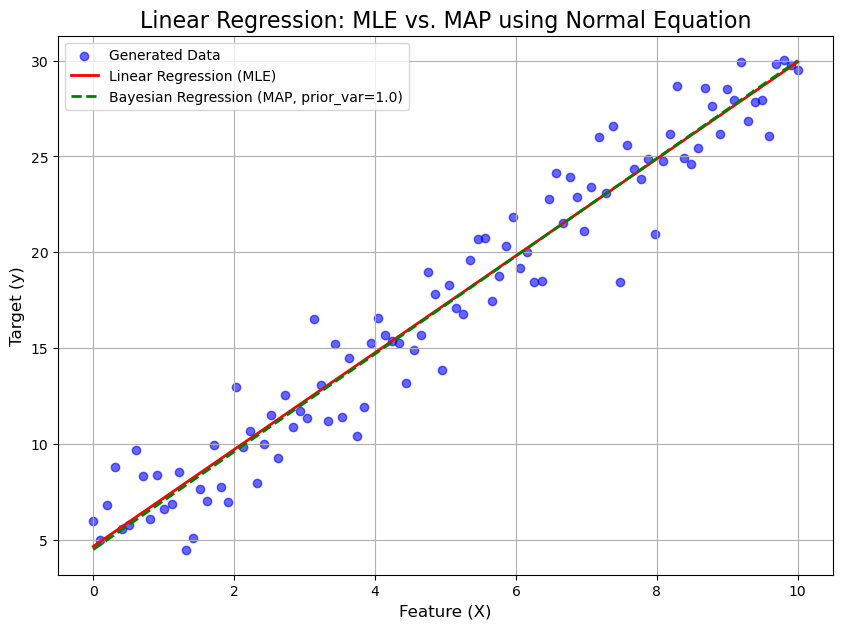

In [3]:
# --- 1. Generate a synthetic dataset ---
np.random.seed(42)
num_points = 100
noise_level = 2.0
X, y = generate_data(num_points, noise_level)

# --- 2. Standard Linear Regression (MLE) using the Normal Equation ---
print("--- Running MLE with Normal Equation ---")
theta_mle = mle_normalEquation(X, y)
print("MLE Parameters (Intercept, Slope):")
print(theta_mle.T)
    
# Predict values for plotting the regression line
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_b = np.c_[np.ones((X_plot.shape[0], 1)), X_plot]
y_mle_pred = X_plot_b.dot(theta_mle)

# --- 3. Bayesian Linear Regression (MAP) using the Normal Equation ---
print("\n--- Running MAP with Normal Equation ---")

# We use a regularization term equivalent to a prior on the parameters
prior_var = 1.0 # This value is chosen to show a clear difference.
theta_map = map_normalEquation(X, y, prior_var)
print("MAP Parameters (Intercept, Slope):")
print(theta_map.T)
    
# Predict values for plotting the Bayesian regression line
y_map_pred = X_plot_b.dot(theta_map)
    
# --- 4. Visualize the results ---
plt.figure(figsize=(10, 7))
plt.scatter(X, y, color='b', label='Generated Data', alpha=0.6)
plt.plot(X_plot, y_mle_pred, 'r-', linewidth=2, label='Linear Regression (MLE)')
plt.plot(X_plot, y_map_pred, 'g--', linewidth=2, label=f'Bayesian Regression (MAP, prior_var={prior_var})')
    
plt.title('Linear Regression: MLE vs. MAP using Normal Equation', fontsize=16)
plt.xlabel('Feature (X)', fontsize=12)
plt.ylabel('Target (y)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [4]:
def gradient_descent(X: np.ndarray, y: np.ndarray, learning_rate: float, num_iterations: int, lambda_reg: float = 0):
    """
    Performs gradient descent to find optimal parameters for linear regression.
    
    This function can be used for both MLE (lambda_reg=0) and MAP (lambda_reg > 0).

    Args:
        X (np.ndarray): The feature matrix (with a column of ones for the intercept).
        y (np.ndarray): The target vector.
        learning_rate (float): The step size for gradient descent.
        num_iterations (int): The number of iterations to run.
        lambda_reg (float): The regularization parameter for MAP. 
                            A value of 0 results in the MLE solution.

    Returns:
        np.ndarray: The optimal parameters (weights) of the model.
    """
    # Augment X with a column of ones for the intercept term
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    m, n = X_b.shape
    
    # Initialize parameters to zeros
    theta = np.zeros((n, 1))
    
    for _ in range(num_iterations):
        # Calculate the hypothesis (predicted values)
        hypothesis = X_b.dot(theta)
        
        # Calculate the error
        error = hypothesis - y
        
        # Calculate the gradient
        gradient = (1/m) * X_b.T.dot(error)
        
        # Add the regularization term to the gradient (excluding the intercept term)
        regularization_gradient = (lambda_reg / m) * theta
        regularization_gradient[0] = 0 # Do not regularize the intercept term
        
        # Update parameters
        theta -= learning_rate * (gradient + regularization_gradient)
        
    return theta

--- Running MLE with Gradient Descent ---
MLE Parameters (Intercept, Slope):
[[1.9515213  0.53819546]]

--- Running MAP with Gradient Descent ---
MAP Parameters (Intercept, Slope):
[[1.96708867 0.53507343]]


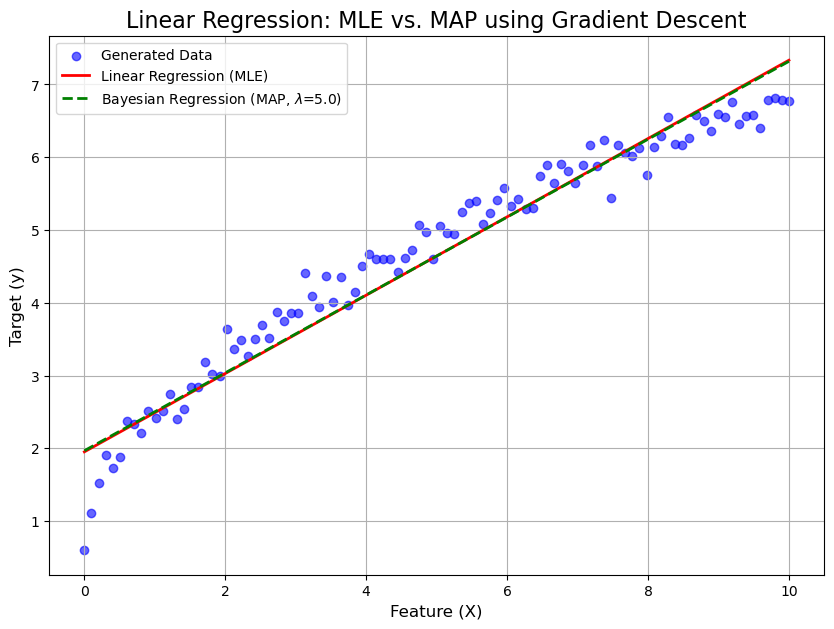

In [17]:
# --- 1. Generate a synthetic dataset ---
np.random.seed(42)
#num_points = 100
noise_level = 0.2
m=100
# Generate random X values
X = np.linspace(0, 10, m).reshape(-1, 1)

a=2.0
b=0.5
# Generate y values with a non-linear relationship and noise
y = a * np.sqrt(X) + b + np.random.normal(0, noise_level, (m, 1))

#X, y = generate_data(num_points, noise_level)

# --- Gradient Descent Parameters ---
learning_rate = 0.01
num_iterations = 1000

# --- 2. Standard Linear Regression (MLE) using Gradient Descent ---
print("--- Running MLE with Gradient Descent ---")
# Here, lambda_reg is 0, so there is no regularization.
theta_mle = gradient_descent(X, y, learning_rate, num_iterations, lambda_reg=0)
print("MLE Parameters (Intercept, Slope):")
print(theta_mle.T)
    
# Predict values for plotting the regression line
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_b = np.c_[np.ones((X_plot.shape[0], 1)), X_plot]
y_mle_pred = X_plot_b.dot(theta_mle)

# --- 3. Bayesian Linear Regression (MAP) using Gradient Descent ---
print("\n--- Running MAP with Gradient Descent ---")
# We use a regularization term equivalent to a prior on the parameters
lambda_map = 5.0 #
theta_map = gradient_descent(X, y, learning_rate, num_iterations, lambda_reg=lambda_map)
print("MAP Parameters (Intercept, Slope):")
print(theta_map.T)
    
# Predict values for plotting the Bayesian regression line
y_map_pred = X_plot_b.dot(theta_map)
    
# --- 4. Visualize the results ---
plt.figure(figsize=(10, 7))
plt.scatter(X, y, color='b', label='Generated Data', alpha=0.6)
plt.plot(X_plot, y_mle_pred, 'r-', linewidth=2, label='Linear Regression (MLE)')
plt.plot(X_plot, y_map_pred, 'g--', linewidth=2, label=f'Bayesian Regression (MAP, $\lambda$={lambda_map})')
    
plt.title('Linear Regression: MLE vs. MAP using Gradient Descent', fontsize=16)
plt.xlabel('Feature (X)', fontsize=12)
plt.ylabel('Target (y)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()